## DECISION DECODING DEEP LEARNING

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed
import time as tm
import pickle

mne.set_log_level('WARNING')
%matplotlib inline

print(f'numpy: {np.__version__}')
print(f'sklearn: {__import__("sklearn").__version__}')
print(f'mne: {mne.__version__}')

numpy: 1.26.4
sklearn: 1.4.2
mne: 1.12.1


In [ ]:
# ruta raiz donde estan las carpetas de cada sujeto
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

# sujetos disponibles 
subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [4]:
# cargamos solo main_epo.fif — unico archivo que necesitamos
# contiene los datos de EEG y la metadata con deci, confi, rDV...
all_main_epochs  = []
all_main_rawdata = []
subjs_ok         = []

for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    file_main = os.path.join(subj_path, 'main_epo.fif')

    if not os.path.exists(file_main):
        print(f'  {subject_id}: falta main_epo.fif, se omite')
        continue

    try:
        main = mne.read_epochs(file_main, preload=True, verbose=False)
        all_main_epochs.append(main)
        all_main_rawdata.append({
            'epoch_dat': main.get_data(),
            'metadata':  main.metadata
        })
        subjs_ok.append(subject_id)
        print(f'  {subject_id} cargado — shape: {main.get_data().shape}')
    except Exception as e:
        print(f'  {subject_id}: error al cargar → {e}')

nSubj  = len(subjs_ok)
time   = all_main_epochs[0].times
n_time = len(time)
print(f'\nTotal sujetos cargados: {nSubj}')
print(f'Timepoints: {n_time}  |  Ventana: {time[0]:.2f}s → {time[-1]:.2f}s')

  s01 cargado — shape: (250, 32, 2876)
  s02 cargado — shape: (261, 32, 2876)
  s03 cargado — shape: (256, 32, 2876)
  s04 cargado — shape: (236, 32, 2876)
  s05 cargado — shape: (243, 32, 2876)
  s06: falta main_epo.fif, se omite
  s07 cargado — shape: (249, 32, 2876)
  s08 cargado — shape: (247, 32, 2876)
  s09 cargado — shape: (193, 32, 2876)
  s0x: falta main_epo.fif, se omite
  s10 cargado — shape: (250, 32, 2876)
  s11 cargado — shape: (251, 32, 2876)
  s12 cargado — shape: (252, 32, 2876)
  s13 cargado — shape: (253, 32, 2876)
  s14 cargado — shape: (261, 32, 2876)
  s15 cargado — shape: (257, 32, 2876)
  s16 cargado — shape: (238, 32, 2876)
  s17 cargado — shape: (260, 32, 2876)
  s18 cargado — shape: (239, 32, 2876)
  s19 cargado — shape: (259, 32, 2876)
  s20 cargado — shape: (248, 32, 2876)
  s21 cargado — shape: (257, 32, 2876)
  s22 cargado — shape: (264, 32, 2876)
  s23 cargado — shape: (255, 32, 2876)
  s24 cargado — shape: (232, 32, 2876)
  s25 cargado — shape: (264, 32

In [5]:
# canales centrales — los mas informativos para la decision segun analisis previos
all_ch_names = all_main_epochs[0].ch_names
central_ch   = ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
central_idx  = [all_ch_names.index(ch) for ch in central_ch]

# ventana de estimulos — la mas informativa para la decision
idx_t = np.where((time >= 1.0) & (time <= 2.5))[0]
n_ch  = len(central_idx)
n_t   = len(idx_t)

# parametros de cross-validation
n_folds          = 5
n_components_pca = 30

# funcion para crear folds estratificados
def create_folds(y_binned, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

print(f'Canales centrales: {central_ch}')
print(f'Ventana: 1.0s → 2.5s ({n_t} timepoints)')
print(f'Features por trial: {n_ch} canales x {n_t} timepoints = {n_ch*n_t}')

Canales centrales: ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
Ventana: 1.0s → 2.5s (751 timepoints)
Features por trial: 7 canales x 751 timepoints = 5257


In [ ]:
# EXPERIMENTO A — MLP (red neuronal) con 5 folds 
# usamos MLPClassifier que es una red neuronal multicapa simple
# es mas potente que LDA porque puede aprender patrones no lineales
# usamos los canales centrales y la ventana de estimulos (1.0s → 2.5s)
# comparamos con LDA para ver si la red neuronal mejora el resultado

# arquitectura de la red neuronal:
# input (n_ch × n_t features) → capa oculta 1 (256 neuronas) → capa oculta 2 (128 neuronas) → output (cardinal/diagonal)
# dropout implicito via early stopping para evitar overfitting

# array donde guardamos la accuracy por sujeto
scorer_mlp_5fold = np.zeros(nSubj)

t_start = tm.time()

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    # construimos la matriz de features con los canales centrales
    # y la ventana de estimulos — (n_trials × n_ch × n_t) → (n_trials × n_ch*n_t)
    X = Y[:, central_idx, :][:, :, idx_t]
    X = X.reshape(X.shape[0], -1)

    # pipeline: estandarizacion + PCA + MLP
    # PCA reduce la dimensionalidad antes de la red neuronal
    # para evitar overfitting con tantos features
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=min(n_components_pca, X.shape[0]-1, X.shape[1]))),
        ('clf',    MLPClassifier(
                        hidden_layer_sizes=(256, 128),  # dos capas ocultas
                        activation='relu',              # funcion de activacion
                        max_iter=500,                   # maximo de iteraciones
                        early_stopping=True,            # para cuando no mejora
                        validation_fraction=0.1,        # 10% para validacion interna
                        random_state=42
                    ))
    ])

    # cross-validation de 5 folds
    folds     = create_folds(labels, n_folds)
    preds_all = np.full(len(labels), np.nan)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        pipe.fit(X[train_ix], labels[train_ix])
        preds_all[test_ix] = pipe.predict(X[test_ix])

    valid                = ~np.isnan(preds_all)
    scorer_mlp_5fold[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))
    print(f'  subj {subjs_ok[isubj]}: {scorer_mlp_5fold[isubj]:.3f}', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nExperimento A completado → {elapsed:.1f} min transcurridos')
print(f'Accuracy media MLP:  {scorer_mlp_5fold.mean():.4f} ± {scorer_mlp_5fold.std()/np.sqrt(nSubj):.4f}')

# guardamos resultados
import pickle
results_mlp = {'scorer_mlp_5fold': scorer_mlp_5fold, 'subjs_ok': subjs_ok}
save_path_mlp = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp.pkl'
with open(save_path_mlp, 'wb') as f:
    pickle.dump(results_mlp, f)
print(f'resultados guardados en: {save_path_mlp}')

  subj s01: 0.624
  subj s02: 0.617
  subj s03: 0.500
  subj s04: 0.475
  subj s05: 0.642
  subj s07: 0.534
  subj s08: 0.551
  subj s09: 0.575
  subj s10: 0.552
  subj s11: 0.494
  subj s12: 0.643
  subj s13: 0.486
  subj s14: 0.586
  subj s15: 0.549
  subj s16: 0.487
  subj s17: 0.588
  subj s18: 0.615
  subj s19: 0.571
  subj s20: 0.536
  subj s21: 0.506
  subj s22: 0.481
  subj s23: 0.486
  subj s24: 0.655
  subj s25: 0.652
  subj s26: 0.552
  subj s27: 0.613

Experimento A completado → 0.5 min transcurridos
Accuracy media MLP:  0.5604 ± 0.0114
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp.pkl


In [ ]:
# EXPERIMENTO B — Transfer Learning (LOSO) 
# LOSO = Leave One Subject Out
# entrenamos con 24 sujetos y testeamos en el que queda fuera
# repetimos para cada sujeto
# la idea es que el modelo aprende patrones generales entre sujetos
# y los aplica a un sujeto nuevo que no ha visto nunca

scorer_mlp_loso = np.zeros(nSubj)

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\ntesteando en: {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    # TEST: sujeto que dejamos fuera 
    Y_test    = all_main_rawdata[isubj]['epoch_dat']
    meta_test = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels_test = np.array(meta_test['deci'], dtype=int)

    X_test = Y_test[:, central_idx, :][:, :, idx_t]
    X_test = X_test.reshape(X_test.shape[0], -1)

    # TRAIN: todos los demas sujetos 
    X_train_list = []
    y_train_list = []

    for jsubj in range(nSubj):
        if jsubj == isubj:
            continue  # saltamos el sujeto de test
        Y_train    = all_main_rawdata[jsubj]['epoch_dat']
        meta_train = all_main_rawdata[jsubj]['metadata'].reset_index(drop=True)
        labels_train = np.array(meta_train['deci'], dtype=int)

        X_train = Y_train[:, central_idx, :][:, :, idx_t]
        X_train = X_train.reshape(X_train.shape[0], -1)

        X_train_list.append(X_train)
        y_train_list.append(labels_train)

    # concatenamos todos los sujetos de entrenamiento
    X_train_all = np.concatenate(X_train_list, axis=0)
    y_train_all = np.concatenate(y_train_list, axis=0)

    print(f'  train: {X_train_all.shape[0]} trials de {nSubj-1} sujetos')
    print(f'  test:  {X_test.shape[0]} trials')

    # pipeline: estandarizacion + PCA + MLP
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=min(n_components_pca,
                                        X_train_all.shape[0]-1,
                                        X_train_all.shape[1]))),
        ('clf',    MLPClassifier(
                        hidden_layer_sizes=(256, 128),
                        activation='relu',
                        max_iter=500,
                        early_stopping=True,
                        validation_fraction=0.1,
                        random_state=42
                    ))
    ])

    pipe.fit(X_train_all, y_train_all)
    preds = pipe.predict(X_test)

    scorer_mlp_loso[isubj] = np.mean(preds == labels_test.astype(float))
    print(f'  accuracy: {scorer_mlp_loso[isubj]:.3f}', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nExperimento B completado → {elapsed:.1f} min transcurridos')
print(f'Accuracy media LOSO: {scorer_mlp_loso.mean():.4f} ± {scorer_mlp_loso.std()/np.sqrt(nSubj):.4f}')

# guardamos resultados
results_loso = {'scorer_mlp_loso': scorer_mlp_loso, 'subjs_ok': subjs_ok}
save_path_loso = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp_loso.pkl'
with open(save_path_loso, 'wb') as f:
    pickle.dump(results_loso, f)
print(f'resultados guardados en: {save_path_loso}')


testeando en: s01 (1/26)
  train: 6211 trials de 25 sujetos
  test:  250 trials
  accuracy: 0.568

testeando en: s02 (2/26)
  train: 6200 trials de 25 sujetos
  test:  261 trials
  accuracy: 0.533

testeando en: s03 (3/26)
  train: 6205 trials de 25 sujetos
  test:  256 trials
  accuracy: 0.562

testeando en: s04 (4/26)
  train: 6225 trials de 25 sujetos
  test:  236 trials
  accuracy: 0.559

testeando en: s05 (5/26)
  train: 6218 trials de 25 sujetos
  test:  243 trials
  accuracy: 0.539

testeando en: s07 (6/26)
  train: 6212 trials de 25 sujetos
  test:  249 trials
  accuracy: 0.474

testeando en: s08 (7/26)
  train: 6214 trials de 25 sujetos
  test:  247 trials
  accuracy: 0.356

testeando en: s09 (8/26)
  train: 6268 trials de 25 sujetos
  test:  193 trials
  accuracy: 0.627

testeando en: s10 (9/26)
  train: 6211 trials de 25 sujetos
  test:  250 trials
  accuracy: 0.488

testeando en: s11 (10/26)
  train: 6210 trials de 25 sujetos
  test:  251 trials
  accuracy: 0.518

testeand

In [ ]:
# EXPERIMENTO C — Data Augmentation + MLP 
# generamos trials sinteticos añadiendo ruido gaussiano a los trials reales
# esto aumenta artificialmente el numero de trials de entrenamiento
# y ayuda al modelo a generalizar mejor — menos overfitting
# por cada trial real generamos 3 trials sinteticos
# el ruido gaussiano tiene una desviacion estandar pequeña (5% de la std de los datos)
# para que los trials sinteticos sean realistas pero distintos de los reales

def augment_data(X, y, n_augmentations=3, noise_factor=0.05):
    # calculamos la desviacion estandar de los datos reales
    noise_std = X.std() * noise_factor
    X_aug_list = [X]  # empezamos con los datos reales
    y_aug_list = [y]

    for _ in range(n_augmentations):
        # añadimos ruido gaussiano a cada trial
        noise = np.random.randn(*X.shape) * noise_std
        X_aug_list.append(X + noise)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

# array donde guardamos la accuracy por sujeto
scorer_mlp_aug = np.zeros(nSubj)

t_start = tm.time()

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    X = Y[:, central_idx, :][:, :, idx_t]
    X = X.reshape(X.shape[0], -1)

    folds     = create_folds(labels, n_folds)
    preds_all = np.full(len(labels), np.nan)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue

        # aplicamos data augmentation solo al training set
        # nunca al test set — eso seria trampa
        X_train_aug, y_train_aug = augment_data(
            X[train_ix], labels[train_ix],
            n_augmentations=3,
            noise_factor=0.05
        )

        print(f'  trials originales: {len(train_ix)} → con augmentation: {len(y_train_aug)}',
              end='\r', flush=True)

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=min(n_components_pca,
                                            X_train_aug.shape[0]-1,
                                            X_train_aug.shape[1]))),
            ('clf',    MLPClassifier(
                            hidden_layer_sizes=(256, 128),
                            activation='relu',
                            max_iter=500,
                            early_stopping=True,
                            validation_fraction=0.1,
                            random_state=42
                        ))
        ])

        pipe.fit(X_train_aug, y_train_aug)
        preds_all[test_ix] = pipe.predict(X[test_ix])

    valid               = ~np.isnan(preds_all)
    scorer_mlp_aug[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))
    print(f'  subj {subjs_ok[isubj]}: {scorer_mlp_aug[isubj]:.3f}', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nExperimento C completado → {elapsed:.1f} min transcurridos')
print(f'Accuracy media MLP + augmentation: {scorer_mlp_aug.mean():.4f} ± {scorer_mlp_aug.std()/np.sqrt(nSubj):.4f}')

# guardamos resultados
results_aug = {'scorer_mlp_aug': scorer_mlp_aug, 'subjs_ok': subjs_ok}
save_path_aug = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp_aug.pkl'
with open(save_path_aug, 'wb') as f:
    pickle.dump(results_aug, f)
print(f'resultados guardados en: {save_path_aug}')

  subj s01: 0.592es: 200 → con augmentation: 800
  subj s02: 0.556es: 209 → con augmentation: 836
  subj s03: 0.508es: 205 → con augmentation: 820
  subj s04: 0.436es: 189 → con augmentation: 756
  subj s05: 0.634es: 195 → con augmentation: 780
  subj s07: 0.498es: 200 → con augmentation: 800
  subj s08: 0.599es: 198 → con augmentation: 792
  subj s09: 0.534es: 155 → con augmentation: 620
  subj s10: 0.520es: 200 → con augmentation: 800
  subj s11: 0.486es: 201 → con augmentation: 804
  subj s12: 0.595es: 202 → con augmentation: 808
  subj s13: 0.506es: 203 → con augmentation: 812
  subj s14: 0.536es: 209 → con augmentation: 836
  subj s15: 0.537es: 206 → con augmentation: 824
  subj s16: 0.534es: 191 → con augmentation: 764
  subj s17: 0.573es: 208 → con augmentation: 832
  subj s18: 0.607es: 192 → con augmentation: 768
  subj s19: 0.571es: 208 → con augmentation: 832
  subj s20: 0.520es: 199 → con augmentation: 796
  subj s21: 0.556es: 206 → con augmentation: 824
  subj s22: 0.439es:

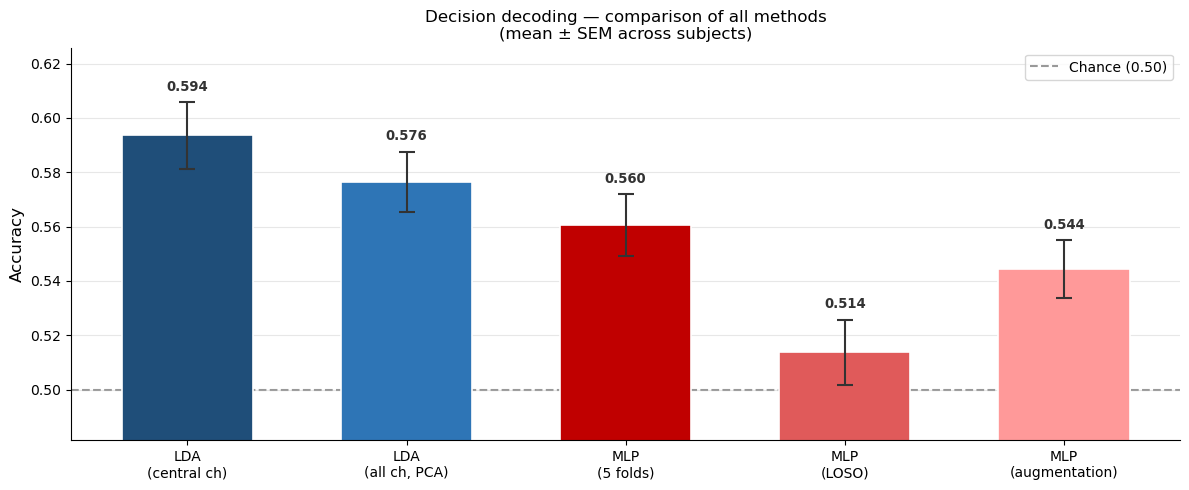


Resumen de todos los metodos:
-------------------------------------------------------
  LDA (central ch)          0.5935 ± 0.0123  (mejora sobre azar: 9.35%)
  LDA (all ch, PCA)         0.5764 ± 0.0112  (mejora sobre azar: 7.64%)
  MLP (5 folds)             0.5604 ± 0.0114  (mejora sobre azar: 6.04%)
  MLP (LOSO)                0.5137 ± 0.0121  (mejora sobre azar: 1.37%)
  MLP (augmentation)        0.5444 ± 0.0106  (mejora sobre azar: 4.44%)


In [ ]:
# PLOT COMPARATIVO — todos los metodos 
# comparamos la accuracy de todos los metodos que hemos probado
# para ver cual es el mejor para decodificar la decision

# cargamos los resultados de los metodos anteriores (notebook de decision)
import pickle

# cargamos LDA y tecnica 4 de la notebook anterior
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_ch_selection.pkl', 'rb') as f:
    results_ch = pickle.load(f)
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_temporal.pkl', 'rb') as f:
    results_temporal = pickle.load(f)

# cargamos los resultados de deep learning
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp.pkl', 'rb') as f:
    results_mlp = pickle.load(f)
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp_loso.pkl', 'rb') as f:
    results_loso = pickle.load(f)
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_mlp_aug.pkl', 'rb') as f:
    results_aug = pickle.load(f)

# calculamos accuracy media en ventana de estimulos para LDA canales centrales
time_loaded = results_ch['time']
idx_window  = np.where((time_loaded >= 1.0) & (time_loaded <= 2.5))[0]
lda_central = results_ch['scorer_ch']['Central'][:, idx_window].mean(axis=1)
lda_all     = results_temporal['scorer_temporal']['Stimulus window (1.0s → 2.5s)']

# organizamos todos los resultados
metodos = {
    'LDA\n(central ch)':       lda_central,
    'LDA\n(all ch, PCA)':      lda_all,
    'MLP\n(5 folds)':          results_mlp['scorer_mlp_5fold'],
    'MLP\n(LOSO)':             results_loso['scorer_mlp_loso'],
    'MLP\n(augmentation)':     results_aug['scorer_mlp_aug'],
}

accs  = [v.mean() for v in metodos.values()]
sems  = [v.std() / np.sqrt(len(v)) for v in metodos.values()]
names = list(metodos.keys())

colors = ['#1f4e79', '#2e75b6', '#c00000', '#e05a5a', '#ff9999']

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(len(names)), accs, color=colors,
              width=0.6, edgecolor='white', linewidth=1.2, zorder=2)
ax.errorbar(range(len(names)), accs, yerr=sems,
            fmt='none', color='#333333', capsize=6, capthick=1.5, lw=1.5, zorder=3)

# etiquetas encima de cada barra
for i, (acc, sem) in enumerate(zip(accs, sems)):
    ax.text(i, acc + sem + 0.003, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#333333')

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8,
           label='Chance (0.50)', zorder=1)

y_min = min(accs) - max(sems) - 0.02
y_max = max(accs) + max(sems) + 0.02
ax.set_ylim([max(0.45, y_min), min(0.75, y_max)])

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding — comparison of all methods\n'
             '(mean ± SEM across subjects)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

# resumen en texto
print('\nResumen de todos los metodos:')
print('-' * 55)
for name, acc, sem in zip(names, accs, sems):
    nombre_limpio = name.replace('\n', ' ')
    print(f'  {nombre_limpio:<25} {acc:.4f} ± {sem:.4f}  '
          f'(mejora sobre azar: {(acc-0.5)*100:.2f}%)')

In [ ]:
# MEJORA 1 — LDA con shrinkage 
# LDA estandar no tiene regularizacion — puede tener overfitting cuando hay
# mas features que trials (nuestro caso: 7 canales × 751 timepoints >> 250 trials)
# LDA con shrinkage='auto' añade regularizacion automatica usando el metodo de Ledoit-Wolf
# esto reduce el overfitting y mejora la generalizacion

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

scorer_lda_shrinkage = np.zeros(nSubj)

t_start = tm.time()

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    # construimos la matriz de features con canales centrales y ventana de estimulos
    X = Y[:, central_idx, :][:, :, idx_t]
    X = X.reshape(X.shape[0], -1)

    # pipeline: estandarizacion + PCA + LDA con shrinkage
    # solver='lsqr' es necesario para usar shrinkage
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=min(n_components_pca, X.shape[0]-1, X.shape[1]))),
        ('clf',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    ])

    folds     = create_folds(labels, n_folds)
    preds_all = np.full(len(labels), np.nan)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        pipe.fit(X[train_ix], labels[train_ix])
        preds_all[test_ix] = pipe.predict(X[test_ix])

    valid = ~np.isnan(preds_all)
    scorer_lda_shrinkage[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))
    print(f'  subj {subjs_ok[isubj]}: {scorer_lda_shrinkage[isubj]:.3f}', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nMejora 1 completada → {elapsed:.1f} min transcurridos')
print(f'Accuracy LDA shrinkage:  {scorer_lda_shrinkage.mean():.4f} ± {scorer_lda_shrinkage.std()/np.sqrt(nSubj):.4f}')
print(f'Accuracy LDA original:   {results_mlp["scorer_mlp_5fold"].mean():.4f}')
print(f'Mejora: {(scorer_lda_shrinkage.mean() - results_mlp["scorer_mlp_5fold"].mean())*100:.2f}%')

# guardamos resultados
results_shrinkage = {'scorer_lda_shrinkage': scorer_lda_shrinkage, 'subjs_ok': subjs_ok}
save_path_shrinkage = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_lda_shrinkage.pkl'
with open(save_path_shrinkage, 'wb') as f:
    pickle.dump(results_shrinkage, f)
print(f'resultados guardados en: {save_path_shrinkage}')

  subj s01: 0.632
  subj s02: 0.613
  subj s03: 0.617
  subj s04: 0.483
  subj s05: 0.663
  subj s07: 0.470
  subj s08: 0.640
  subj s09: 0.601
  subj s10: 0.552
  subj s11: 0.526
  subj s12: 0.607
  subj s13: 0.502
  subj s14: 0.594
  subj s15: 0.560
  subj s16: 0.529
  subj s17: 0.612
  subj s18: 0.657
  subj s19: 0.625
  subj s20: 0.556
  subj s21: 0.572
  subj s22: 0.508
  subj s23: 0.557
  subj s24: 0.694
  subj s25: 0.644
  subj s26: 0.517
  subj s27: 0.645

Mejora 1 completada → 0.2 min transcurridos
Accuracy LDA shrinkage:  0.5837 ± 0.0116
Accuracy LDA original:   0.5604
Mejora: 2.33%
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_lda_shrinkage.pkl


In [ ]:
# MEJORA 2 — Features espectrales + LDA 
# en vez de usar la amplitud del EEG en cada timepoint,
# extraemos la potencia en bandas de frecuencia relevantes para la decision:
# theta (4-8Hz)  → memoria de trabajo y acumulacion de evidencia
# alpha (8-12Hz) → inhibicion y atencion
# beta (13-30Hz) → mantenimiento de decisiones
# usamos los canales centrales en la ventana de estimulos (1.0s → 2.5s)

from scipy.signal import welch

def extract_spectral_features(Y, ch_idx, t_idx, sfreq=500):
    # extraemos la ventana temporal de interes
    Y_win = Y[:, :, :][:, ch_idx, :][:, :, t_idx]  # (n_trials × n_ch × n_t)
    n_trials, n_ch, n_t = Y_win.shape

    # definimos las bandas de frecuencia
    bands = {
        'theta': (4,  8),
        'alpha': (8,  12),
        'beta':  (13, 30),
    }

    # para cada trial y cada canal calculamos la potencia en cada banda
    features = []
    for itrial in range(n_trials):
        trial_features = []
        for ich in range(n_ch):
            # calculamos el espectro de potencia con Welch
            freqs, psd = welch(Y_win[itrial, ich, :], fs=sfreq, nperseg=min(256, n_t))
            # extraemos la potencia media en cada banda
            for band_name, (f_low, f_high) in bands.items():
                idx_band = np.where((freqs >= f_low) & (freqs <= f_high))[0]
                trial_features.append(psd[idx_band].mean())
        features.append(trial_features)

    return np.array(features)  # (n_trials × n_ch*n_bands)

# array donde guardamos la accuracy por sujeto
scorer_spectral = np.zeros(nSubj)

t_start = tm.time()

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    # extraemos features espectrales — (n_trials × n_ch*n_bandas)
    X = extract_spectral_features(Y, central_idx, idx_t)
    print(f'  subj {subjs_ok[isubj]} — features shape: {X.shape}', end='', flush=True)

    # pipeline: estandarizacion + LDA con shrinkage
    # no necesitamos PCA porque ya tenemos pocos features (7 canales × 3 bandas = 21)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    ])

    folds     = create_folds(labels, n_folds)
    preds_all = np.full(len(labels), np.nan)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        pipe.fit(X[train_ix], labels[train_ix])
        preds_all[test_ix] = pipe.predict(X[test_ix])

    valid = ~np.isnan(preds_all)
    scorer_spectral[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))
    print(f'  accuracy: {scorer_spectral[isubj]:.3f}', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nMejora 2 completada → {elapsed:.1f} min transcurridos')
print(f'Accuracy LDA spectral:   {scorer_spectral.mean():.4f} ± {scorer_spectral.std()/np.sqrt(nSubj):.4f}')
print(f'Accuracy LDA central:    0.5935')
print(f'Accuracy LDA shrinkage:  {scorer_lda_shrinkage.mean():.4f}')

# guardamos resultados
results_spectral = {'scorer_spectral': scorer_spectral, 'subjs_ok': subjs_ok}
save_path_spectral = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_spectral.pkl'
with open(save_path_spectral, 'wb') as f:
    pickle.dump(results_spectral, f)
print(f'resultados guardados en: {save_path_spectral}')

  subj s01 — features shape: (250, 21)  accuracy: 0.672
  subj s02 — features shape: (261, 21)  accuracy: 0.621
  subj s03 — features shape: (256, 21)  accuracy: 0.555
  subj s04 — features shape: (236, 21)  accuracy: 0.500
  subj s05 — features shape: (243, 21)  accuracy: 0.695
  subj s07 — features shape: (249, 21)  accuracy: 0.542
  subj s08 — features shape: (247, 21)  accuracy: 0.652
  subj s09 — features shape: (193, 21)  accuracy: 0.648
  subj s10 — features shape: (250, 21)  accuracy: 0.512
  subj s11 — features shape: (251, 21)  accuracy: 0.550
  subj s12 — features shape: (252, 21)  accuracy: 0.667
  subj s13 — features shape: (253, 21)  accuracy: 0.542
  subj s14 — features shape: (261, 21)  accuracy: 0.594
  subj s15 — features shape: (257, 21)  accuracy: 0.502
  subj s16 — features shape: (238, 21)  accuracy: 0.462
  subj s17 — features shape: (260, 21)  accuracy: 0.669
  subj s18 — features shape: (239, 21)  accuracy: 0.632
  subj s19 — features shape: (259, 21)  accuracy

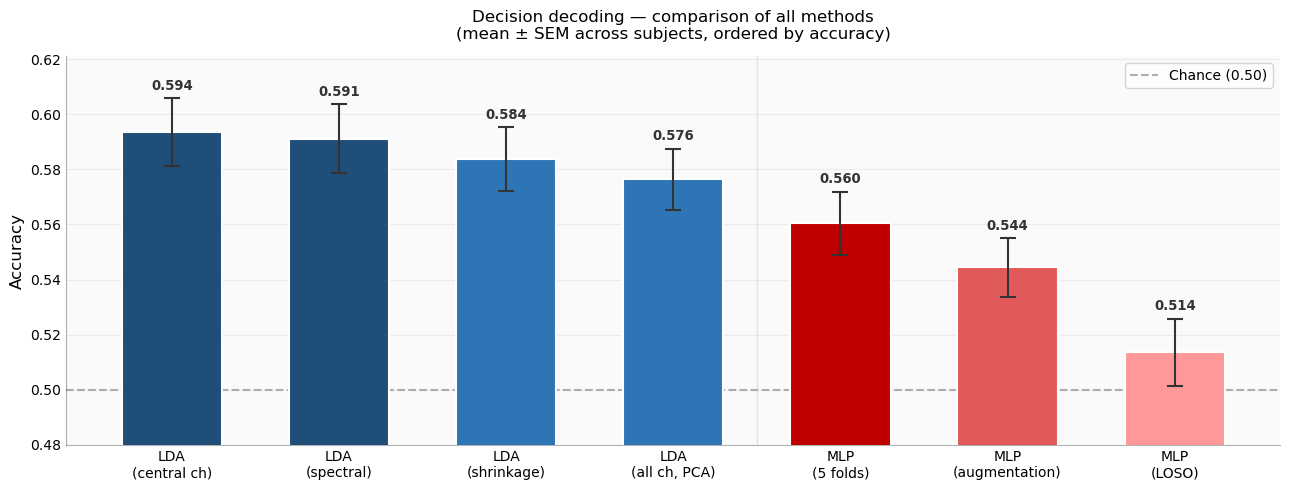


Resumen final — todos los metodos:
----------------------------------------------------------
  LDA (central ch)          0.5935 ± 0.0123  (9.35% sobre azar)
  LDA (spectral)            0.5911 ± 0.0126  (9.11% sobre azar)
  LDA (shrinkage)           0.5837 ± 0.0116  (8.37% sobre azar)
  LDA (all ch, PCA)         0.5764 ± 0.0112  (7.64% sobre azar)
  MLP (5 folds)             0.5604 ± 0.0114  (6.04% sobre azar)
  MLP (augmentation)        0.5444 ± 0.0106  (4.44% sobre azar)
  MLP (LOSO)                0.5137 ± 0.0121  (1.37% sobre azar)


In [ ]:
# PLOT COMPARATIVO FINAL con todos los metodos 
# resumen visual de todos los metodos probados para decodificar la decision
# ordenados de mayor a menor accuracy para facilitar la comparacion

import pickle
import numpy as np
import matplotlib.pyplot as plt

# cargamos todos los resultados
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_ch_selection.pkl', 'rb') as f:
    results_ch = pickle.load(f)
with open('/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_temporal.pkl', 'rb') as f:
    results_temporal = pickle.load(f)

# accuracy LDA central en ventana de estimulos
time_loaded = results_ch['time']
idx_window  = np.where((time_loaded >= 1.0) & (time_loaded <= 2.5))[0]
lda_central = results_ch['scorer_ch']['Central'][:, idx_window].mean(axis=1)
lda_all     = results_temporal['scorer_temporal']['Stimulus window (1.0s → 2.5s)']

# organizamos todos los metodos ordenados de mayor a menor accuracy
metodos = {
    'LDA\n(central ch)':      lda_central,
    'LDA\n(spectral)':        scorer_spectral,
    'LDA\n(all ch, PCA)':     lda_all,
    'LDA\n(shrinkage)':       scorer_lda_shrinkage,
    'MLP\n(5 folds)':         results_mlp['scorer_mlp_5fold'],
    'MLP\n(augmentation)':    results_aug['scorer_mlp_aug'],
    'MLP\n(LOSO)':            results_loso['scorer_mlp_loso'],
}

accs  = [v.mean() for v in metodos.values()]
sems  = [v.std() / np.sqrt(len(v)) for v in metodos.values()]
names = list(metodos.keys())

# ordenamos de mayor a menor accuracy
order  = np.argsort(accs)[::-1]
accs   = [accs[i] for i in order]
sems   = [sems[i] for i in order]
names  = [names[i] for i in order]

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(range(len(names)), accs,
              color=['#1f4e79', '#1f4e79', '#2e75b6', '#2e75b6',
                     '#c00000', '#e05a5a', '#ff9999'],
              width=0.6, edgecolor='white', linewidth=1.5, zorder=2)

ax.errorbar(range(len(names)), accs, yerr=sems,
            fmt='none', color='#333333',
            capsize=6, capthick=1.5, lw=1.5, zorder=3)

# etiquetas encima de cada barra
for i, (acc, sem) in enumerate(zip(accs, sems)):
    ax.text(i, acc + sem + 0.002, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#333333')

# linea de azar
ax.axhline(0.5, color='#999999', ls='--', lw=1.5,
           alpha=0.8, label='Chance (0.50)', zorder=1)

# linea vertical separando LDA y MLP
ax.axvline(3.5, color='#cccccc', ls='-', lw=1, alpha=0.5, zorder=1)

# adaptamos el eje Y
y_min = min(accs) - max(sems) - 0.03
y_max = max(accs) + max(sems) + 0.015
ax.set_ylim([max(0.48, y_min), min(0.75, y_max)])

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding — comparison of all methods\n'
             '(mean ± SEM across subjects, ordered by accuracy)',
             fontsize=12, pad=12)
ax.legend(fontsize=10, framealpha=0.8, edgecolor='#cccccc')

# estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)
ax.tick_params(axis='both', which='both', length=0)
ax.grid(axis='y', alpha=0.2, linestyle='-', zorder=0)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# resumen en texto
print('\nResumen final — todos los metodos:')
print('-' * 58)
for name, acc, sem in zip(names, accs, sems):
    nombre_limpio = name.replace('\n', ' ')
    print(f'  {nombre_limpio:<25} {acc:.4f} ± {sem:.4f}  '
          f'({(acc-0.5)*100:.2f}% sobre azar)')

## DECODING DE LA CONFIANZA

In [15]:
import warnings
warnings.filterwarnings('ignore')


subj s01 (1/26)
  confi decodificada  → max rho: 0.321
  → 0.2 min transcurridos

subj s02 (2/26)
  confi decodificada  → max rho: 0.247
  → 0.3 min transcurridos

subj s03 (3/26)
  confi decodificada  → max rho: 0.293
  → 0.3 min transcurridos

subj s04 (4/26)
  confi decodificada  → max rho: 0.462
  → 0.5 min transcurridos

subj s05 (5/26)
  confi decodificada  → max rho: 0.284
  → 0.6 min transcurridos

subj s07 (6/26)
  confi decodificada  → max rho: 0.260
  → 0.7 min transcurridos

subj s08 (7/26)
  confi decodificada  → max rho: 0.434
  → 0.8 min transcurridos

subj s09 (8/26)
  confi decodificada  → max rho: 0.348
  → 0.9 min transcurridos

subj s10 (9/26)
  confi decodificada  → max rho: 0.257
  → 1.0 min transcurridos

subj s11 (10/26)
  confi decodificada  → max rho: 0.289
  → 1.2 min transcurridos

subj s12 (11/26)
  confi decodificada  → max rho: 0.318
  → 1.5 min transcurridos

subj s13 (12/26)
  confi decodificada  → max rho: 0.428
  → 1.8 min transcurridos

subj s14 (13

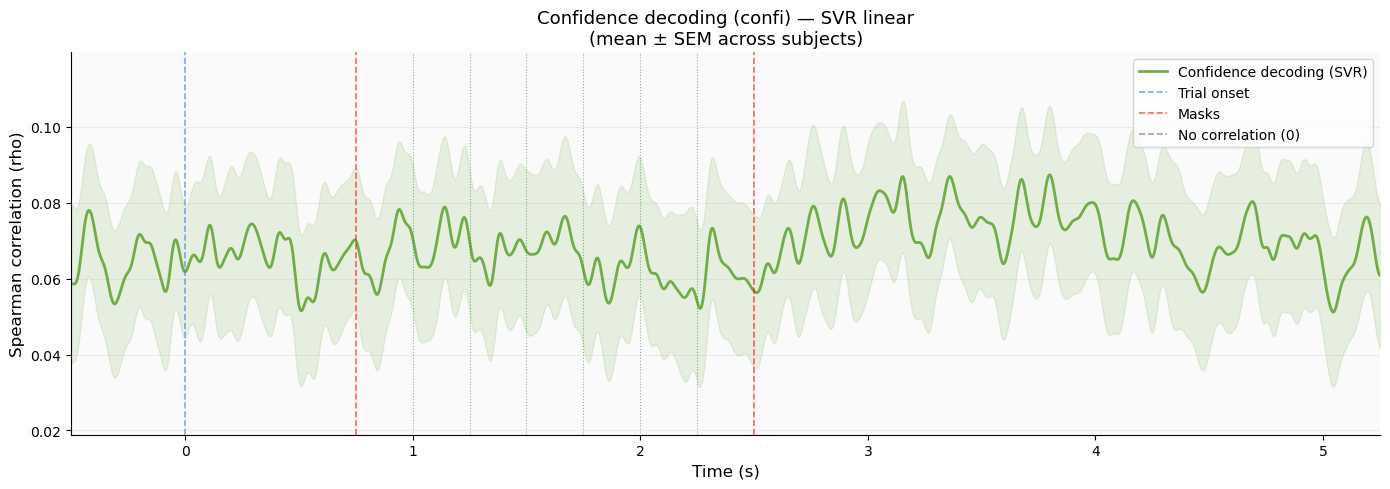

In [ ]:
# DECODING DE LA CONFIANZA (confi) — SVR lineal punto a punto 
# queremos saber en que momento del trial el cerebro codifica la confianza
# confi es una variable continua que va de -1 a 1
# usamos SVR lineal con 5 folds — igual que el decoding de orientaciones
# pero sin transformacion circular porque la confianza no es circular
# la metrica es la correlacion de Spearman entre confianza real y predicha

from sklearn.svm import LinearSVR
from scipy.stats import spearmanr
from joblib import Parallel, delayed

# funcion que procesa un solo timepoint — se ejecutara en paralelo
def decode_timepoint_confi(it, Y, confi, folds):
    import warnings
    warnings.filterwarnings('ignore')
    Ytime  = Y[:, :, it] # actividad de todos los trials en ese instante exacto
    scaler = StandardScaler().fit(Ytime) # estandarizamos los datos
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(confi), np.nan)
    clf    = LinearSVR(max_iter=5000, C=0.1) # SVR lineal

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        clf.fit(Ytime[train_ix], confi[train_ix]) # entrena con los trials de entrenamiento
        preds[test_ix] = clf.predict(Ytime[test_ix]) # predice la confianza de los trials de test

    # calculamos la correlacion de Spearman entre confianza real y predicha
    valid = ~np.isnan(preds)
    if valid.sum() < 3:
        return 0.0
    rho, _ = spearmanr(confi[valid], preds[valid])
    return rho

# parameters
n_folds   = 5
bins_confi = 4  # bins para estratificar los folds por confianza

# array donde guardamos los resultados (n_sujetos × n_timepoints)
scorer_confi = np.zeros((nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']  # (n_trials × 32 × 2876)
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    # confianza continua de -1 a 1
    confi = np.array(metadata['confi'], dtype=float)

    # estratificamos los folds por bins de confianza
    # porque confi es continua necesitamos discretizarla para estratificar
    confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
    folds        = create_folds(confi_binned, n_folds)

    # procesamos todos los timepoints en paralelo
    results_par = Parallel(n_jobs=-1)(
        delayed(decode_timepoint_confi)(it, Y, confi, folds)
        for it in range(n_time)
    )

    scorer_confi[isubj] = np.array(results_par)
    print(f'  confi decodificada  → max rho: {scorer_confi[isubj].max():.3f}', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de confi completado — shape: {scorer_confi.shape}')

# guardamos resultados
results_confi = {
    'scorer_confi': scorer_confi,
    'time':         time,
    'subjs_ok':     subjs_ok,
}

save_path_confi = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_confi.pkl'
with open(save_path_confi, 'wb') as f:
    pickle.dump(results_confi, f)

print(f'resultados guardados en: {save_path_confi}')

# plot
sigma = 10
scorer_confi_smooth = gaussian_filter1d(scorer_confi, sigma=sigma, axis=1)
scorer_mean = np.mean(scorer_confi_smooth, axis=0)
scorer_sem  = np.std(scorer_confi_smooth, axis=0) / np.sqrt(nSubj)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, scorer_mean, color='#70ad47', lw=2, label='Confidence decoding (SVR)')
ax.fill_between(time, scorer_mean - scorer_sem, scorer_mean + scorer_sem,
                color='#70ad47', alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7, label='No correlation (0)')

# adaptamos el eje Y
y_min = scorer_mean.min() - scorer_sem.max() - 0.01
y_max = scorer_mean.max() + scorer_sem.max() + 0.01
ax.set_ylim([y_min, y_max])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Spearman correlation (rho)', fontsize=12)
ax.set_title('Confidence decoding (confi) — SVR linear\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

  subj s01 ✓  subj s02 ✓  subj s03 ✓  subj s04 ✓  subj s05 ✓  subj s07 ✓  subj s08 ✓  subj s09 ✓  subj s10 ✓  subj s11 ✓  subj s12 ✓  subj s13 ✓  subj s14 ✓  subj s15 ✓  subj s16 ✓  subj s17 ✓  subj s18 ✓  subj s19 ✓  subj s20 ✓  subj s21 ✓  subj s22 ✓  subj s23 ✓  subj s24 ✓  subj s25 ✓  subj s26 ✓  subj s27 ✓
decoding de confi por nrep completado
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_confi_nrep.pkl


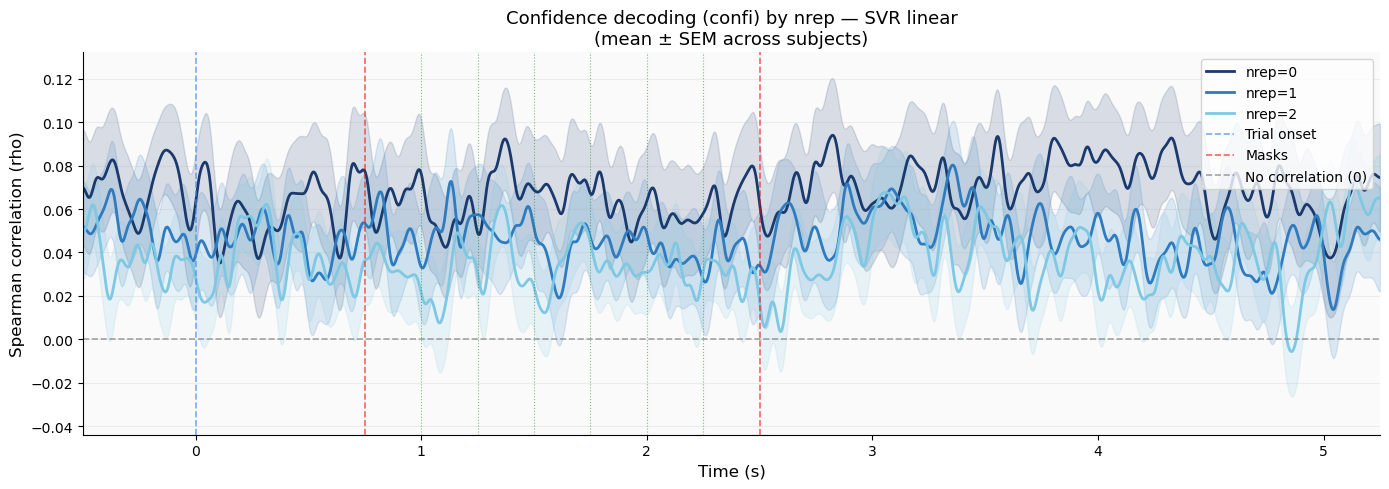

In [ ]:
# DECODING DE CONFI POR NREP 
# reutilizamos las predicciones ya calculadas en la celda anterior
# filtramos los trials por nrep y calculamos la correlacion de Spearman
# para cada nrep por separado
# si el sesgo de confirmacion aumenta con las repeticiones, esperamos ver
# que la correlacion sube con nrep — el cerebro codifica mejor la confianza
# cuando ya ha visto la secuencia antes

import warnings
warnings.filterwarnings('ignore')

nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

# array donde guardamos los resultados por nrep (n_nreps × n_sujetos × n_timepoints)
scorer_confi_nrep = np.zeros((len(nreps), nSubj, n_time))

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    confi    = np.array(metadata['confi'], dtype=float)

    # estratificamos los folds por bins de confianza
    confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
    folds        = create_folds(confi_binned, n_folds)

    # recalculamos las predicciones para todos los timepoints
    results_par = Parallel(n_jobs=-1)(
        delayed(decode_timepoint_confi)(it, Y, confi, folds)
        for it in range(n_time)
    )
    preds_full = np.array(results_par)  # (n_time,) — scores globales ya calculados

    # ahora filtramos por nrep y recalculamos el score
    for i_nrep, nrep in enumerate(nreps):
        idx_nrep = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) == 0:
            continue

        confi_nrep = confi[idx_nrep]
        Y_nrep     = Y[idx_nrep]

        # recalculamos predicciones solo con los trials de este nrep
        confi_binned_nrep = np.digitize(confi_nrep,
                                         np.percentile(confi_nrep, [25, 50, 75]))
        # necesitamos al menos n_folds trials por bin
        if len(idx_nrep) < n_folds:
            continue

        folds_nrep  = create_folds(confi_binned_nrep, n_folds)
        results_nrep = Parallel(n_jobs=-1)(
            delayed(decode_timepoint_confi)(it, Y_nrep, confi_nrep, folds_nrep)
            for it in range(n_time)
        )
        scorer_confi_nrep[i_nrep, isubj] = np.array(results_nrep)

    print(f'  subj {subjs_ok[isubj]} ✓', end='', flush=True)

print('\ndecoding de confi por nrep completado')

# guardamos resultados
results_confi_nrep = {
    'scorer_confi_nrep': scorer_confi_nrep,
    'time':              time,
    'subjs_ok':          subjs_ok,
}

save_path_confi_nrep = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_confi_nrep.pkl'
with open(save_path_confi_nrep, 'wb') as f:
    pickle.dump(results_confi_nrep, f)

print(f'resultados guardados en: {save_path_confi_nrep}')

# plot
sigma = 10
scorer_confi_nrep_smooth = gaussian_filter1d(scorer_confi_nrep, sigma=sigma, axis=2)

fig, ax = plt.subplots(figsize=(14, 5))

for i_nrep, nrep in enumerate(nreps):
    mean = np.mean(scorer_confi_nrep_smooth[i_nrep], axis=0)
    sem  = np.std(scorer_confi_nrep_smooth[i_nrep], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=colors_nrep[i_nrep], lw=2, label=f'nrep={nrep}')
    ax.fill_between(time, mean - sem, mean + sem,
                    color=colors_nrep[i_nrep], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7, label='No correlation (0)')

# adaptamos el eje Y
all_means = [np.mean(scorer_confi_nrep_smooth[i], axis=0) for i in range(len(nreps))]
all_sems  = [np.std(scorer_confi_nrep_smooth[i], axis=0) / np.sqrt(nSubj) for i in range(len(nreps))]
y_min = min(m.min() for m in all_means) - max(s.max() for s in all_sems) - 0.01
y_max = max(m.max() for m in all_means) + max(s.max() for s in all_sems) + 0.01
ax.set_ylim([y_min, y_max])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Spearman correlation (rho)', fontsize=12)
ax.set_title('Confidence decoding (confi) by nrep — SVR linear\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

In [ ]:
# VISUALIZACION DE PREDICCIONES TRIAL A TRIAL — CONFI 
# mostramos las predicciones individuales de un sujeto concreto
# usando el timepoint mas informativo (mayor correlacion de Spearman)
# y calculamos el error medio entre confianza real y predicha

import warnings
warnings.filterwarnings('ignore')

# seleccionamos un sujeto de ejemplo
isubj_example = 0
print(f'Sujeto de ejemplo: {subjs_ok[isubj_example]}')

Y        = all_main_rawdata[isubj_example]['epoch_dat']
metadata = all_main_rawdata[isubj_example]['metadata'].reset_index(drop=True)
confi    = np.array(metadata['confi'], dtype=float)

# encontramos el timepoint con mayor correlacion de Spearman
best_t = np.argmax(np.mean(scorer_confi, axis=0))
print(f'Timepoint mas informativo: t={time[best_t]:.3f}s (indice {best_t})')

# obtenemos las predicciones trial a trial en ese timepoint
confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
folds        = create_folds(confi_binned, n_folds)

Ytime  = Y[:, :, best_t]
scaler = StandardScaler().fit(Ytime)
Ytime  = scaler.transform(Ytime)

preds_example = np.full(len(confi), np.nan)
clf = LinearSVR(max_iter=5000, C=0.1, dual=True)

for fold in folds:
    train_ix = fold['train_index']
    test_ix  = fold['test_index']
    clf.fit(Ytime[train_ix], confi[train_ix])
    preds_example[test_ix] = clf.predict(Ytime[test_ix])

# tabla de predicciones trial a trial
print(f'\nPredicciones trial a trial — {subjs_ok[isubj_example]} (t={time[best_t]:.3f}s)')
print(f'{"Trial":<8} {"Confianza real":<18} {"Confianza predicha":<20} {"Error":<8}')
print('-' * 58)

errores = []
for i in range(len(confi)):
    real  = confi[i]
    pred  = preds_example[i] if not np.isnan(preds_example[i]) else np.nan
    error = abs(real - pred) if not np.isnan(pred) else np.nan
    if not np.isnan(error):
        errores.append(error)
    if i < 20:
        print(f'{i+1:<8} {real:<18.3f} {pred:<20.3f} {error:<8.3f}')

print(f'...')
print(f'\nTotal trials: {len(confi)}')
print(f'Error medio:  {np.mean(errores):.4f}')
print(f'Error std:    {np.std(errores):.4f}')

# error medio por sujeto
print(f'\nError medio por sujeto (timepoint t={time[best_t]:.3f}s):')
print('-' * 45)

errores_subjs = []
for isubj in range(nSubj):
    Y_s      = all_main_rawdata[isubj]['epoch_dat']
    meta_s   = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    confi_s  = np.array(meta_s['confi'], dtype=float)

    confi_binned_s = np.digitize(confi_s, np.percentile(confi_s, [25, 50, 75]))
    folds_s        = create_folds(confi_binned_s, n_folds)

    Ytime_s  = Y_s[:, :, best_t]
    scaler_s = StandardScaler().fit(Ytime_s)
    Ytime_s  = scaler_s.transform(Ytime_s)

    preds_s = np.full(len(confi_s), np.nan)
    clf_s   = LinearSVR(max_iter=5000, C=0.1, dual=True)

    for fold in folds_s:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        clf_s.fit(Ytime_s[train_ix], confi_s[train_ix])
        preds_s[test_ix] = clf_s.predict(Ytime_s[test_ix])

    valid   = ~np.isnan(preds_s)
    error_s = np.mean(np.abs(confi_s[valid] - preds_s[valid]))
    errores_subjs.append(error_s)
    print(f'  {subjs_ok[isubj]:<8} error medio: {error_s:.4f}')

print(f'\nError medio global: {np.mean(errores_subjs):.4f} ± {np.std(errores_subjs)/np.sqrt(nSubj):.4f}')
print(f'Error relativo: {np.mean(errores_subjs)/2.0*100:.1f}% del rango total')

Sujeto de ejemplo: s01
Timepoint mas informativo: t=3.678s (indice 2089)

Predicciones trial a trial — s01 (t=3.678s)
Trial    Confianza real     Confianza predicha   Error   
----------------------------------------------------------
1        -0.100             0.625                0.725   
2        0.600              0.347                0.253   
3        0.850              0.705                0.145   
4        0.500              0.534                0.034   
5        0.800              0.251                0.549   
6        0.800              0.613                0.187   
7        1.000              0.617                0.383   
8        0.600              0.453                0.147   
9        0.900              0.699                0.201   
10       0.500              0.531                0.031   
11       0.750              0.678                0.072   
12       0.900              0.512                0.388   
13       0.600              0.719                0.119   
14       0.

# PRUEBA PARA VER SI MEJORA LA PREDICCION DE LA CONFI 

Modelo 1: entrena con EEG solo → predice confianza

Modelo 2: entrena con conducta sola → predice confianza

Modelo 3: entrena con EEG + conducta → predice confianza



In [ ]:
# MODELO 1 — Solo EEG 
# ya lo tenemos calculado en scorer_confi
# usamos el resultado existente como baseline

print('Modelo 1 — Solo EEG:')
print(f'  Correlacion de Spearman media: {np.mean(scorer_confi):.4f}')
print(f'  En ventana de estimulos (1.0s → 2.5s): '
      f'{np.mean(scorer_confi[:, np.where((time >= 1.0) & (time <= 2.5))[0]]):.4f}')

Modelo 1 — Solo EEG:
  Correlacion de Spearman media: 0.0683
  En ventana de estimulos (1.0s → 2.5s): 0.0648


In [ ]:
# MODELO 2 
# predecimos la confianza usando solo variables conductuales
# sin ninguna informacion del EEG
# esto nos da el baseline conductual — cuanto se puede predecir sin EEG

from sklearn.svm import SVR
from scipy.stats import spearmanr

scorer_conducta = np.zeros(nSubj)

for isubj in range(nSubj):
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    confi    = np.array(metadata['confi'], dtype=float)

    # features conductuales: correct, RT, deci, rDV, nrep
    X_cond = np.column_stack([
        np.array(metadata['correct'], dtype=float),
        np.array(metadata['RT'],      dtype=float),
        np.array(metadata['deci'],    dtype=float),
        np.array(metadata['rDV'],     dtype=float),
        np.array(metadata['nrep'],    dtype=float),
    ])

    # estandarizamos
    scaler = StandardScaler().fit(X_cond)
    X_cond = scaler.transform(X_cond)

    # cross-validation de 5 folds
    confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
    folds        = create_folds(confi_binned, n_folds)
    preds_all    = np.full(len(confi), np.nan)
    clf          = SVR(kernel='linear', C=0.1)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        clf.fit(X_cond[train_ix], confi[train_ix])
        preds_all[test_ix] = clf.predict(X_cond[test_ix])

    valid = ~np.isnan(preds_all)
    rho, _ = spearmanr(confi[valid], preds_all[valid])
    scorer_conducta[isubj] = rho
    print(f'  subj {subjs_ok[isubj]}: rho={rho:.3f}', flush=True)

print(f'\nModelo 2 — Solo conducta:')
print(f'  Correlacion de Spearman media: {scorer_conducta.mean():.4f} ± {scorer_conducta.std()/np.sqrt(nSubj):.4f}')

  subj s01: rho=0.511
  subj s02: rho=0.372
  subj s03: rho=0.384
  subj s04: rho=0.146
  subj s05: rho=0.292
  subj s07: rho=0.312
  subj s08: rho=0.464
  subj s09: rho=0.433
  subj s10: rho=0.535
  subj s11: rho=0.277
  subj s12: rho=0.242
  subj s13: rho=0.351
  subj s14: rho=0.304
  subj s15: rho=0.441
  subj s16: rho=0.267
  subj s17: rho=0.474
  subj s18: rho=0.115
  subj s19: rho=0.474
  subj s20: rho=0.369
  subj s21: rho=0.355
  subj s22: rho=0.481
  subj s23: rho=0.184
  subj s24: rho=0.426
  subj s25: rho=0.445
  subj s26: rho=0.277
  subj s27: rho=0.213

Modelo 2 — Solo conducta:
  Correlacion de Spearman media: 0.3517 ± 0.0222


Timepoint mas informativo: t=3.678s
  subj s01: rho=0.453
  subj s02: rho=0.257
  subj s03: rho=0.340
  subj s04: rho=0.399
  subj s05: rho=0.287
  subj s07: rho=0.209
  subj s08: rho=0.514
  subj s09: rho=0.402
  subj s10: rho=0.488
  subj s11: rho=0.237
  subj s12: rho=0.224
  subj s13: rho=0.454
  subj s14: rho=0.257
  subj s15: rho=0.276
  subj s16: rho=0.256
  subj s17: rho=0.510
  subj s18: rho=0.155
  subj s19: rho=0.418
  subj s20: rho=0.374
  subj s21: rho=0.354
  subj s22: rho=0.418
  subj s23: rho=0.139
  subj s24: rho=0.313
  subj s25: rho=0.479
  subj s26: rho=0.148
  subj s27: rho=0.267

Modelo 3 — EEG + conducta:
  Correlacion de Spearman media: 0.3319 ± 0.0222


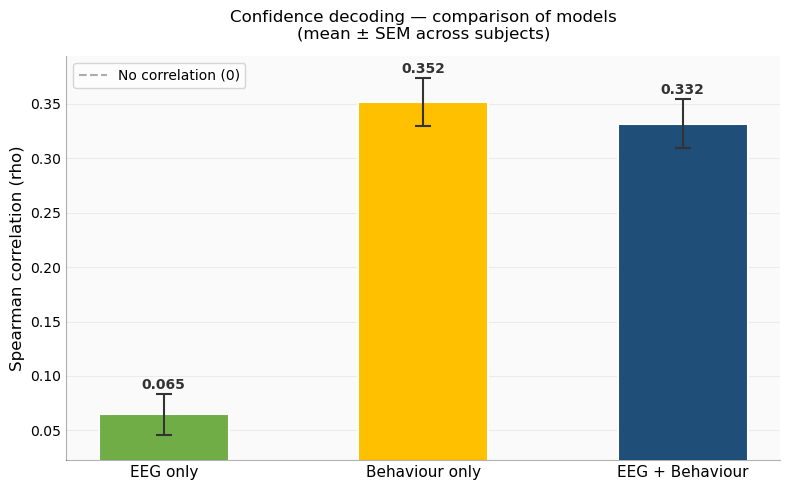


Resumen comparativo:
--------------------------------------------------
  EEG only             rho=0.0648 ± 0.0187
  Behaviour only       rho=0.3517 ± 0.0222
  EEG + Behaviour      rho=0.3319 ± 0.0222


In [ ]:
# MODELO 3 — EEG + conducta 
# combinamos la actividad EEG en el timepoint mas informativo
# con las variables conductuales
# queremos ver si el EEG aporta informacion adicional sobre la confianza
# mas alla de lo que ya predice la conducta sola

scorer_eeg_cond = np.zeros(nSubj)

# usamos el timepoint mas informativo del EEG
best_t = np.argmax(np.mean(scorer_confi, axis=0))
print(f'Timepoint mas informativo: t={time[best_t]:.3f}s')

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    confi    = np.array(metadata['confi'], dtype=float)

    # features EEG en el timepoint mas informativo
    X_eeg = Y[:, :, best_t]  # (n_trials × 32)

    # features conductuales
    X_cond = np.column_stack([
        np.array(metadata['correct'], dtype=float),
        np.array(metadata['RT'],      dtype=float),
        np.array(metadata['deci'],    dtype=float),
        np.array(metadata['rDV'],     dtype=float),
        np.array(metadata['nrep'],    dtype=float),
    ])

    # combinamos EEG + conducta
    X_combined = np.concatenate([X_eeg, X_cond], axis=1)  # (n_trials × 37)

    # pipeline: estandarizacion + PCA + SVR
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=min(n_components_pca,
                                        X_combined.shape[0]-1,
                                        X_combined.shape[1]))),
        ('clf',    SVR(kernel='linear', C=0.1))
    ])

    confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
    folds        = create_folds(confi_binned, n_folds)
    preds_all    = np.full(len(confi), np.nan)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        pipe.fit(X_combined[train_ix], confi[train_ix])
        preds_all[test_ix] = pipe.predict(X_combined[test_ix])

    valid = ~np.isnan(preds_all)
    rho, _ = spearmanr(confi[valid], preds_all[valid])
    scorer_eeg_cond[isubj] = rho
    print(f'  subj {subjs_ok[isubj]}: rho={rho:.3f}', flush=True)

print(f'\nModelo 3 — EEG + conducta:')
print(f'  Correlacion de Spearman media: {scorer_eeg_cond.mean():.4f} ± {scorer_eeg_cond.std()/np.sqrt(nSubj):.4f}')



idx_window = np.where((time >= 1.0) & (time <= 2.5))[0]

modelos = {
    'EEG only':           np.mean(scorer_confi[:, idx_window], axis=1),
    'Behaviour only':     scorer_conducta,
    'EEG + Behaviour':    scorer_eeg_cond,
}

accs  = [v.mean() for v in modelos.values()]
sems  = [v.std() / np.sqrt(len(v)) for v in modelos.values()]
names = list(modelos.keys())
colors = ['#70ad47', '#ffc000', '#1f4e79']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(range(len(names)), accs, color=colors,
              width=0.5, edgecolor='white', linewidth=1.5, zorder=2)
ax.errorbar(range(len(names)), accs, yerr=sems,
            fmt='none', color='#333333',
            capsize=6, capthick=1.5, lw=1.5, zorder=3)

for i, (acc, sem) in enumerate(zip(accs, sems)):
    ax.text(i, acc + sem + 0.002, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#333333')

ax.axhline(0, color='#999999', ls='--', lw=1.5,
           alpha=0.8, label='No correlation (0)', zorder=1)

y_min = min(accs) - max(sems) - 0.02
y_max = max(accs) + max(sems) + 0.02
ax.set_ylim([y_min, y_max])

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Spearman correlation (rho)', fontsize=12)
ax.set_title('Confidence decoding — comparison of models\n'
             '(mean ± SEM across subjects)', fontsize=12, pad=12)
ax.legend(fontsize=10, framealpha=0.8, edgecolor='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)
ax.tick_params(axis='both', which='both', length=0)
ax.grid(axis='y', alpha=0.2, linestyle='-', zorder=0)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print('\nResumen comparativo:')
print('-' * 50)
for name, acc, sem in zip(names, accs, sems):
    print(f'  {name:<20} rho={acc:.4f} ± {sem:.4f}')


subj s01 (1/26)
  max rho: 0.572
  → 0.2 min transcurridos

subj s02 (2/26)
  max rho: 0.477
  → 0.3 min transcurridos

subj s03 (3/26)
  max rho: 0.462
  → 0.4 min transcurridos

subj s04 (4/26)
  max rho: 0.491
  → 0.6 min transcurridos

subj s05 (5/26)
  max rho: 0.384
  → 0.7 min transcurridos

subj s07 (6/26)
  max rho: 0.437
  → 0.8 min transcurridos

subj s08 (7/26)
  max rho: 0.619
  → 1.0 min transcurridos

subj s09 (8/26)
  max rho: 0.512
  → 1.1 min transcurridos

subj s10 (9/26)
  max rho: 0.591
  → 1.2 min transcurridos

subj s11 (10/26)
  max rho: 0.392
  → 1.4 min transcurridos

subj s12 (11/26)
  max rho: 0.406
  → 1.7 min transcurridos

subj s13 (12/26)
  max rho: 0.548
  → 2.2 min transcurridos

subj s14 (13/26)
  max rho: 0.405
  → 2.4 min transcurridos

subj s15 (14/26)
  max rho: 0.523
  → 2.6 min transcurridos

subj s16 (15/26)
  max rho: 0.394
  → 3.0 min transcurridos

subj s17 (16/26)
  max rho: 0.538
  → 3.1 min transcurridos

subj s18 (17/26)
  max rho: 0.31

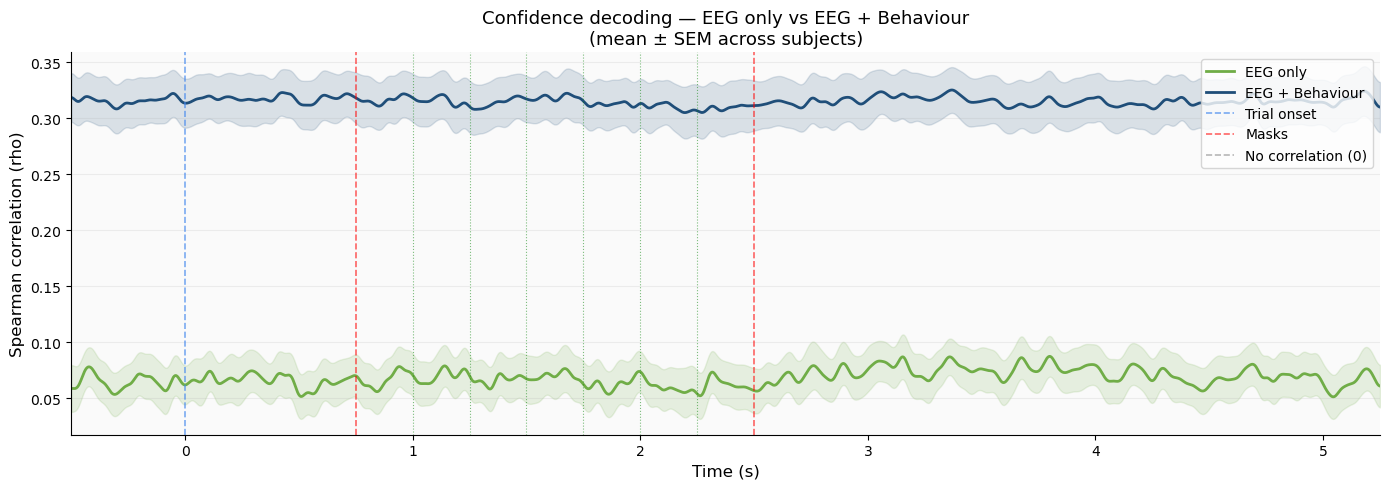

In [ ]:
# DECODING PUNTO A PUNTO — EEG + conducta 
# igual que el decoding de confi con solo EEG pero añadiendo las variables
# conductuales como features adicionales en cada timepoint
# para cada timepoint t:
#   X = [actividad EEG en t (32 canales) + correct + RT + deci + rDV + nrep]
#   y = confianza
# comparamos la curva resultante con la de EEG solo

import warnings
warnings.filterwarnings('ignore')

# funcion que procesa un solo timepoint con EEG + conducta
def decode_timepoint_confi_combined(it, Y, confi, X_cond, folds):
    import warnings
    warnings.filterwarnings('ignore')
    Ytime  = Y[:, :, it] # actividad EEG en ese instante (n_trials × 32)
    # combinamos EEG + conducta → (n_trials × 37)
    X_combined = np.concatenate([Ytime, X_cond], axis=1)
    scaler = StandardScaler().fit(X_combined)
    X_combined = scaler.transform(X_combined)
    preds  = np.full(len(confi), np.nan)
    clf    = LinearSVR(max_iter=5000, C=0.1, dual=True)

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        clf.fit(X_combined[train_ix], confi[train_ix])
        preds[test_ix] = clf.predict(X_combined[test_ix])

    valid = ~np.isnan(preds)
    if valid.sum() < 3:
        return 0.0
    rho, _ = spearmanr(confi[valid], preds[valid])
    return rho

# array donde guardamos los resultados (n_sujetos × n_timepoints)
scorer_confi_combined = np.zeros((nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    confi    = np.array(metadata['confi'], dtype=float)

    # features conductuales — iguales para todos los timepoints
    X_cond = np.column_stack([
        np.array(metadata['correct'], dtype=float),
        np.array(metadata['RT'],      dtype=float),
        np.array(metadata['deci'],    dtype=float),
        np.array(metadata['rDV'],     dtype=float),
        np.array(metadata['nrep'],    dtype=float),
    ])

    # estratificamos los folds por bins de confianza
    confi_binned = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
    folds        = create_folds(confi_binned, n_folds)

    # procesamos todos los timepoints en paralelo
    results_par = Parallel(n_jobs=-1)(
        delayed(decode_timepoint_confi_combined)(it, Y, confi, X_cond, folds)
        for it in range(n_time)
    )

    scorer_confi_combined[isubj] = np.array(results_par)
    print(f'  max rho: {scorer_confi_combined[isubj].max():.3f}', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding EEG + conducta completado — shape: {scorer_confi_combined.shape}')

# guardamos resultados
results_confi_combined = {
    'scorer_confi_combined': scorer_confi_combined,
    'time':                  time,
    'subjs_ok':              subjs_ok,
}

save_path_confi_combined = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_confi_combined.pkl'
with open(save_path_confi_combined, 'wb') as f:
    pickle.dump(results_confi_combined, f)

print(f'resultados guardados en: {save_path_confi_combined}')

# plot — comparacion EEG solo vs EEG + conducta
sigma = 10
scorer_confi_smooth          = gaussian_filter1d(scorer_confi, sigma=sigma, axis=1)
scorer_confi_combined_smooth = gaussian_filter1d(scorer_confi_combined, sigma=sigma, axis=1)

mean_eeg      = np.mean(scorer_confi_smooth, axis=0)
sem_eeg       = np.std(scorer_confi_smooth, axis=0) / np.sqrt(nSubj)
mean_combined = np.mean(scorer_confi_combined_smooth, axis=0)
sem_combined  = np.std(scorer_confi_combined_smooth, axis=0) / np.sqrt(nSubj)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, mean_eeg, color='#70ad47', lw=2, label='EEG only')
ax.fill_between(time, mean_eeg - sem_eeg, mean_eeg + sem_eeg,
                color='#70ad47', alpha=0.15)

ax.plot(time, mean_combined, color='#1f4e79', lw=2, label='EEG + Behaviour')
ax.fill_between(time, mean_combined - sem_combined, mean_combined + sem_combined,
                color='#1f4e79', alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0, color='#999999', ls='--', lw=1.2, alpha=0.7, label='No correlation (0)')

# adaptamos el eje Y
all_means = [mean_eeg, mean_combined]
all_sems  = [sem_eeg, sem_combined]
y_min = min(m.min() for m in all_means) - max(s.max() for s in all_sems) - 0.01
y_max = max(m.max() for m in all_means) + max(s.max() for s in all_sems) + 0.01
ax.set_ylim([y_min, y_max])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Spearman correlation (rho)', fontsize=12)
ax.set_title('Confidence decoding — EEG only vs EEG + Behaviour\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

In [ ]:
# TABLA DE PREDICCIONES TRIAL A TRIAL — EEG + CONDUCTA 
# mostramos las predicciones individuales de un sujeto concreto
# usando el timepoint mas informativo y la combinacion EEG + conducta

import warnings
warnings.filterwarnings('ignore')

# seleccionamos un sujeto de ejemplo
isubj_example = 0
print(f'Sujeto de ejemplo: {subjs_ok[isubj_example]}')

Y        = all_main_rawdata[isubj_example]['epoch_dat']
metadata = all_main_rawdata[isubj_example]['metadata'].reset_index(drop=True)
confi    = np.array(metadata['confi'], dtype=float)

# features conductuales
X_cond = np.column_stack([
    np.array(metadata['correct'], dtype=float),
    np.array(metadata['RT'],      dtype=float),
    np.array(metadata['deci'],    dtype=float),
    np.array(metadata['rDV'],     dtype=float),
    np.array(metadata['nrep'],    dtype=float),
])

# encontramos el timepoint mas informativo para EEG + conducta
best_t = np.argmax(np.mean(scorer_confi_combined, axis=0))
print(f'Timepoint mas informativo: t={time[best_t]:.3f}s')

# construimos X combinado en ese timepoint
Ytime      = Y[:, :, best_t]
X_combined = np.concatenate([Ytime, X_cond], axis=1)

scaler     = StandardScaler().fit(X_combined)
X_combined = scaler.transform(X_combined)

# cross-validation de 5 folds
confi_binned  = np.digitize(confi, np.percentile(confi, [25, 50, 75]))
folds         = create_folds(confi_binned, n_folds)
preds_example = np.full(len(confi), np.nan)
clf           = LinearSVR(max_iter=10000, C=0.1, dual=True)

for fold in folds:
    train_ix = fold['train_index']
    test_ix  = fold['test_index']
    clf.fit(X_combined[train_ix], confi[train_ix])
    preds_example[test_ix] = clf.predict(X_combined[test_ix])

# tabla de predicciones
print(f'\nPredicciones trial a trial — {subjs_ok[isubj_example]} (t={time[best_t]:.3f}s)')
print(f'{"Trial":<8} {"Confianza real":<18} {"Confianza predicha":<20} {"Error":<8}')
print('-' * 58)

errores = []
for i in range(len(confi)):
    real  = confi[i]
    pred  = preds_example[i] if not np.isnan(preds_example[i]) else np.nan
    error = abs(real - pred) if not np.isnan(pred) else np.nan
    if not np.isnan(error):
        errores.append(error)
    if i < 20:
        print(f'{i+1:<8} {real:<18.3f} {pred:<20.3f} {error:<8.3f}')

print(f'...')
print(f'\nTotal trials: {len(confi)}')
print(f'Error medio:  {np.mean(errores):.4f}')
print(f'Error std:    {np.std(errores):.4f}')
print(f'Error relativo: {np.mean(errores)/2.0*100:.1f}% del rango total (-1 a 1)')

# comparacion con EEG solo
print(f'\nComparacion de errores:')
print(f'  EEG only      → rho = {np.mean(scorer_confi[:, best_t]):.4f}')
print(f'  EEG + Behaviour → rho = {np.mean(scorer_confi_combined[:, best_t]):.4f}')

Sujeto de ejemplo: s01
Timepoint mas informativo: t=4.688s

Predicciones trial a trial — s01 (t=4.688s)
Trial    Confianza real     Confianza predicha   Error   
----------------------------------------------------------
1        -0.100             0.079                0.179   
2        0.600              0.460                0.140   
3        0.850              0.504                0.346   
4        0.500              0.604                0.104   
5        0.800              0.786                0.014   
6        0.800              0.931                0.131   
7        1.000              0.496                0.504   
8        0.600              0.510                0.090   
9        0.900              0.948                0.048   
10       0.500              0.602                0.102   
11       0.750              0.779                0.029   
12       0.900              0.605                0.295   
13       0.600              0.650                0.050   
14       0.900           